In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [5]:
import plotly.express as px

In [6]:
import os

In [7]:
os.listdir(r"C:\Users\muley\Downloads\Uber\Datasets")

['other-American_B01362.csv',
 'other-Carmel_B00256.csv',
 'other-Dial7_B00887.csv',
 'other-Diplo_B01196.csv',
 'other-Federal_02216.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Highclass_B01717.csv',
 'other-Lyft_B02510.csv',
 'other-Prestige_B01338.csv',
 'other-Skyline_B00111.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-janjune-15.csv',
 'uber-raw-data-janjune-15_sample.csv',
 'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv']

In [8]:
uber_15 = pd.read_csv(r"C:\Users\muley\Downloads\Uber\Datasets\uber-raw-data-janjune-15_sample.csv")

In [9]:
uber_15

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-02 21:43:00,B02764,237
1,B02682,2015-01-20 19:52:59,B02682,231
2,B02617,2015-03-19 20:26:00,B02617,161
3,B02764,2015-04-10 17:38:00,B02764,107
4,B02764,2015-03-23 07:03:00,B00111,140
...,...,...,...,...
99995,B02764,2015-04-13 16:12:00,B02764,234
99996,B02764,2015-03-06 21:32:00,B02764,24
99997,B02598,2015-03-19 19:56:00,B02598,17
99998,B02682,2015-05-02 16:02:00,B02682,68


In [10]:
type(uber_15)

pandas.core.frame.DataFrame

**data cleaning**

In [11]:
uber_15.shape

(100000, 4)

In [12]:
uber_15.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

In [13]:
uber_15[uber_15.duplicated(keep=False)].sort_values(by = uber_15.columns.tolist())


,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
63404,B02598,2015-02-01 14:25:37,B02598,234
64734,B02598,2015-02-01 14:25:37,B02598,234
69742,B02598,2015-03-30 14:03:00,B02598,137
80080,B02598,2015-03-30 14:03:00,B02598,137
48594,B02598,2015-05-17 00:09:00,B02598,170
...,...,...,...,...
62914,B02765,2015-04-04 15:39:00,B02765,133
72891,B02765,2015-04-12 02:44:00,B02765,158
77361,B02765,2015-04-12 02:44:00,B02765,158
94553,B02765,2015-04-25 19:18:00,B02765,236


In [14]:
uber_15.drop_duplicates(inplace=True)

In [15]:
uber_15.duplicated().sum()

np.int64(0)

In [16]:
uber_15.shape

(99946, 4)

In [17]:
uber_15.isnull()

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
99995,False,False,False,False
99996,False,False,False,False
99997,False,False,False,False
99998,False,False,False,False


In [18]:
uber_15.isnull().sum()

Dispatching_base_num       0
Pickup_date                0
Affiliated_base_num     1116
locationID                 0
dtype: int64

In [19]:
uber_15.dtypes

Dispatching_base_num    object
Pickup_date             object
Affiliated_base_num     object
locationID               int64
dtype: object

In [20]:
uber_15["Pickup_date"] = pd.to_datetime(uber_15["Pickup_date"])

In [21]:
uber_15.dtypes

Dispatching_base_num            object
Pickup_date             datetime64[ns]
Affiliated_base_num             object
locationID                       int64
dtype: object

In [22]:
uber_15["Pickup_date"][0]

Timestamp('2015-05-02 21:43:00')

***which month have max.Uber pickups in new york city?***

In [23]:
uber_15

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-02 21:43:00,B02764,237
1,B02682,2015-01-20 19:52:59,B02682,231
2,B02617,2015-03-19 20:26:00,B02617,161
3,B02764,2015-04-10 17:38:00,B02764,107
4,B02764,2015-03-23 07:03:00,B00111,140
...,...,...,...,...
99995,B02764,2015-04-13 16:12:00,B02764,234
99996,B02764,2015-03-06 21:32:00,B02764,24
99997,B02598,2015-03-19 19:56:00,B02598,17
99998,B02682,2015-05-02 16:02:00,B02682,68


In [24]:
uber_15["month"] = uber_15["Pickup_date"].dt.month_name()
uber_15["weekday"] = uber_15["Pickup_date"].dt.day_name()
uber_15["day"] = uber_15["Pickup_date"].dt.day
uber_15["hour"] = uber_15["Pickup_date"].dt.hour
uber_15["minute"] = uber_15["Pickup_date"].dt.minute

In [25]:
uber_15["month"]

0            May
1        January
2          March
3          April
4          March
          ...   
99995      April
99996      March
99997      March
99998        May
99999       June
Name: month, Length: 99946, dtype: object

<Axes: xlabel='month'>

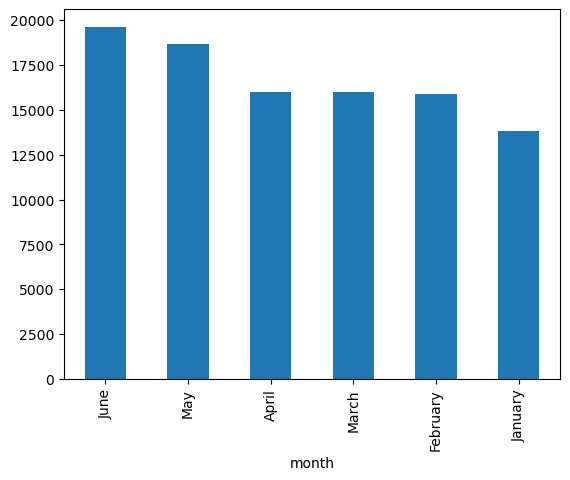

In [26]:
uber_15["month"].value_counts().plot(kind="bar")

In [27]:
uber_15.head(4)

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,weekday,day,hour,minute
0,B02617,2015-05-02 21:43:00,B02764,237,May,Saturday,2,21,43
1,B02682,2015-01-20 19:52:59,B02682,231,January,Tuesday,20,19,52
2,B02617,2015-03-19 20:26:00,B02617,161,March,Thursday,19,20,26
3,B02764,2015-04-10 17:38:00,B02764,107,April,Friday,10,17,38


In [28]:
pivot = pd.crosstab(index = uber_15["month"],columns = uber_15["weekday"])

In [29]:
pivot

weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
month,,,,,,,
April,2365,1833,2508,2052,2823,1880,2521
February,2655,1970,2550,2183,2396,2129,2013
January,2508,1353,2745,1651,2378,1444,1740
June,2793,2848,3037,2485,2767,3187,2503
March,2465,2115,2522,2379,2093,2388,2007
May,3262,1865,3519,2944,2627,2115,2328


In [30]:
month_order = ['January','February','March','April','May','June']
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

In [31]:
pivot_sorted = pivot.reindex(index = month_order).reindex(columns = weekday_order)

In [32]:
pivot_sorted

weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
month,,,,,,,
January,1353,1444,1740,2378,2508,2745,1651
February,1970,2129,2013,2396,2655,2550,2183
March,2115,2388,2007,2093,2465,2522,2379
April,1833,1880,2521,2823,2365,2508,2052
May,1865,2115,2328,2627,3262,3519,2944
June,2848,3187,2503,2767,2793,3037,2485


In [33]:
fig=px.bar(pivot_sorted, 
       x = pivot_sorted.index,
       y = pivot_sorted.columns,
       barmode="group",
       title="Uber pickups by month and weekday")

In [34]:
fig.update_layout(
    xaxis_title= "Month",
    yaxis_title="Number of Pickups",
    legend_title="Weekday")

**find out hourly rush**

In [35]:
uber_15.columns

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID', 'month', 'weekday', 'day', 'hour', 'minute'],
      dtype='object')

In [36]:
hourly_rush=uber_15.groupby(['weekday','hour'],as_index=False).size()

In [37]:
hourly_rush

,weekday,hour,size
0,Friday,0,581
1,Friday,1,333
2,Friday,2,197
3,Friday,3,138
4,Friday,4,161
...,...,...,...
163,Wednesday,19,1044
164,Wednesday,20,897
165,Wednesday,21,949
166,Wednesday,22,900


In [38]:
hourly_rush=hourly_rush.sort_values(["weekday","hour"])
hourly_rush

,weekday,hour,size
0,Friday,0,581
1,Friday,1,333
2,Friday,2,197
3,Friday,3,138
4,Friday,4,161
...,...,...,...
163,Wednesday,19,1044
164,Wednesday,20,897
165,Wednesday,21,949
166,Wednesday,22,900


In [39]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

In [40]:
pd.Categorical(hourly_rush["weekday"],categories=weekday_order,ordered=True)

['Friday', 'Friday', 'Friday', 'Friday', 'Friday', ..., 'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday']
Length: 168
Categories (7, object): ['Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday' < 'Saturday' < 'Sunday']

In [41]:
hourly_rush1=hourly_rush.sort_values(["weekday","hour"])

In [42]:
hourly_rush1

,weekday,hour,size
0,Friday,0,581
1,Friday,1,333
2,Friday,2,197
3,Friday,3,138
4,Friday,4,161
...,...,...,...
163,Wednesday,19,1044
164,Wednesday,20,897
165,Wednesday,21,949
166,Wednesday,22,900


In [43]:
px.line(hourly_rush,
        x="hour",
        y="size",
        color="weekday",
        markers=True,
        title="hourly uber rush by days")

**Pareto Analysis:**

In [44]:
uber_15.head(1)

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,weekday,day,hour,minute
0,B02617,2015-05-02 21:43:00,B02764,237,May,Saturday,2,21,43


In [45]:
base_counts = uber_15["Dispatching_base_num"].value_counts()

In [46]:
base_counts

Dispatching_base_num
B02764    40267
B02682    24460
B02617    14496
B02598    10644
B02765     8120
B02512     1757
B02835      193
B02836        9
Name: count, dtype: int64

In [47]:
base_counts.sum()

np.int64(99946)

In [48]:
base_counts/base_counts.sum()

Dispatching_base_num
B02764    0.402888
B02682    0.244732
B02617    0.145038
B02598    0.106498
B02765    0.081244
B02512    0.017579
B02835    0.001931
B02836    0.000090
Name: count, dtype: float64

In [49]:
(base_counts/base_counts.sum()).cumsum()

Dispatching_base_num
B02764    0.402888
B02682    0.647620
B02617    0.792658
B02598    0.899156
B02765    0.980399
B02512    0.997979
B02835    0.999910
B02836    1.000000
Name: count, dtype: float64

In [50]:
base_df = base_counts.reset_index()

In [51]:
base_df.columns = ["Base","Trips"]

In [52]:
base_df

,Base,Trips
0,B02764,40267
1,B02682,24460
2,B02617,14496
3,B02598,10644
4,B02765,8120
5,B02512,1757
6,B02835,193
7,B02836,9


In [53]:
base_df["Trip_Percentage"]= base_df["Trips"]/base_df["Trips"].sum()

In [54]:
base_df

,Base,Trips,Trip_Percentage
0,B02764,40267,0.402888
1,B02682,24460,0.244732
2,B02617,14496,0.145038
3,B02598,10644,0.106498
4,B02765,8120,0.081244
5,B02512,1757,0.017579
6,B02835,193,0.001931
7,B02836,9,0.000090


In [55]:
base_df["cumulative_Percentage"] = base_df["Trip_Percentage"].cumsum()

In [56]:
base_df

,Base,Trips,Trip_Percentage,cumulative_Percentage
0,B02764,40267,0.402888,0.402888
1,B02682,24460,0.244732,0.647620
2,B02617,14496,0.145038,0.792658
3,B02598,10644,0.106498,0.899156
4,B02765,8120,0.081244,0.980399
5,B02512,1757,0.017579,0.997979
6,B02835,193,0.001931,0.999910
7,B02836,9,0.000090,1.000000


In [57]:
import plotly.graph_objs as go

In [58]:
pareto= go.Figure([
    go.Bar(x = base_df["Base"],y=base_df["Trips"],name="Trips"),
    go.Scatter(x=base_df["Base"],y = base_df["cumulative_Percentage"],
              yaxis= 'y2',
              mode="lines+markers",
              name="Cumulative %")
])

In [59]:
pareto

In [60]:
pareto = pareto.update_layout(yaxis2 = dict(overlaying = 'y' , side = "right", tickformat = ".0%",range=[0,1]))
pareto = pareto.add_hline(y=0.8,yref = 'y2',line_dash= "dash")
pareto

**Airport Demand Analysis**

In [61]:
uber_15["locationID"].unique()

array([237, 231, 161, 107, 140,  87, 125,  68, 163, 235, 112, 233, 262,
       132, 141, 170, 226,  42,  48, 158, 148, 186, 246,  25, 164,  97,
       138,  76, 143, 200, 238, 239, 144, 232, 162, 236, 113, 229,  15,
         4,  40,  49, 106, 100,  79, 114, 155, 165, 149, 197,  74, 211,
       119,  88, 142, 249, 234, 263,  35,  22, 228, 181, 137, 255, 210,
        72,  41,  36, 230, 209, 123,  37,  13,  50, 225,  45,  28, 256,
        66,  65,  61, 224,  17,  82,  70, 151,  56, 157,   7, 223,  11,
        85,  43, 166,  90, 188, 227, 192,  33, 145, 261,  52, 258,  24,
        14, 135,  80, 134,  95, 102, 174, 216, 193, 241,  18, 185, 259,
       260, 130, 215,  75, 220, 179, 121, 212,  62, 160,  92, 116, 243,
       247, 146, 244, 248, 257, 178,  26, 133, 214, 124, 198,  73,  39,
        78, 129,  89, 128,  71, 171, 180,  10, 175, 126, 203,  83, 219,
        69, 196, 190, 189,  63, 150, 156, 213,   3, 183,  53,  91,  77,
       250, 168, 202, 205,  54, 177, 152, 195, 159,  86, 242,  2

In [62]:
airport_ids = [1,132,138]

In [63]:
airport_df = uber_15[uber_15["locationID"].isin(airport_ids)]

In [64]:
airport_df

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,weekday,day,hour,minute
15,B02617,2015-02-20 17:25:18,B02617,132,February,Friday,20,17,25
35,B02764,2015-04-12 17:28:00,B01998,138,April,Sunday,12,17,28
124,B02764,2015-03-19 16:06:00,B02764,138,March,Thursday,19,16,6
150,B02682,2015-03-28 22:53:00,B02598,138,March,Saturday,28,22,53
154,B02617,2015-01-09 02:10:51,B02617,138,January,Friday,9,2,10
...,...,...,...,...,...,...,...,...,...
99827,B02764,2015-06-10 22:30:00,B02764,138,June,Wednesday,10,22,30
99884,B02765,2015-04-28 00:45:00,B02769,132,April,Tuesday,28,0,45
99898,B02682,2015-05-29 00:11:00,B02682,132,May,Friday,29,0,11
99925,B02682,2015-05-18 11:32:00,B02682,138,May,Monday,18,11,32


In [65]:
airport_map  = {
     1: "EWR",
     132: "JFK",
    138: "LGA"
}

In [66]:
airport_df.loc[:, "airport_name"] = airport_df["locationID"].map(airport_map)

C:\Users\muley\AppData\Local\Temp\ipykernel_16752\800722778.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [67]:
airport_df["airport_name"].value_counts()

airport_name
JFK    1948
LGA    1923
Name: count, dtype: int64

In [68]:
airport_df.loc[:,"hour"]= airport_df["Pickup_date"].dt.hour

In [69]:
airport_df.columns

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID', 'month', 'weekday', 'day', 'hour', 'minute',
       'airport_name'],
      dtype='object')

In [70]:
airport_hourly = airport_df.groupby(["airport_name", 'hour']).size().reset_index(name = "trips")
airport_hourly

,airport_name,hour,trips
0,JFK,0,129
1,JFK,1,46
2,JFK,2,17
3,JFK,3,4
4,JFK,4,7
5,JFK,5,44
6,JFK,6,99
7,JFK,7,70
8,JFK,8,69
9,JFK,9,31


In [71]:
area=px.area(airport_hourly , 
        x = "hour",
        y = "trips",
        color= "airport_name",
       title = "Airport Demand Pressure")

In [72]:
area

**collect entire data and make it ready for data analysis** 

In [73]:
import os

In [74]:
files = os.listdir(r"C:\Users\muley\Downloads\Uber\Datasets")

In [75]:
files

['other-American_B01362.csv',
 'other-Carmel_B00256.csv',
 'other-Dial7_B00887.csv',
 'other-Diplo_B01196.csv',
 'other-Federal_02216.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Highclass_B01717.csv',
 'other-Lyft_B02510.csv',
 'other-Prestige_B01338.csv',
 'other-Skyline_B00111.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-janjune-15.csv',
 'uber-raw-data-janjune-15_sample.csv',
 'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv']

In [76]:
files_csv = ['uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv' ,
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv']

In [77]:
final = pd.DataFrame()

path = r"C:\Users\muley\Downloads\Uber\Datasets"

for file in files_csv:
    current_df = pd.read_csv(path + '/' + file)
    final = pd.concat([current_df , final])

In [78]:
final.shape

(4534327, 4)

In [79]:
final.duplicated().sum()

np.int64(82581)

In [80]:
final.drop_duplicates(inplace = True)

In [81]:
final.shape

(4451746, 4)

In [82]:
final.head(3)

,Date/Time,Lat,Lon,Base
0,8/1/2014 0:03:00,40.7366,-73.9906,B02512
1,8/1/2014 0:09:00,40.7260,-73.9918,B02512
2,8/1/2014 0:12:00,40.7209,-74.0507,B02512


**Data Loading**

In [83]:
final.to_csv(r"C:\Users\muley\Downloads\Uber\Preprocessed data/uber_full_data.csv",index=False)

In [84]:
pip install sqlalchemy

In [85]:
from sqlalchemy import create_engine

In [86]:
engine = create_engine(r'sqlite:///C:\Users\muley\Downloads\Uber\Preprocessed data/uber_db.sqlite')

In [87]:
final.to_sql('Trips', con = engine , if_exists="append")

4451746

**Hourly Rush via animated spatial Analysis**

In [88]:
final.dtypes

Date/Time     object
Lat          float64
Lon          float64
Base          object
dtype: object

In [89]:
final['Date/Time'] = pd.to_datetime(final['Date/Time'])

In [90]:
final["hour"]=final['Date/Time'].dt.hour

In [91]:
final.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base', 'hour'], dtype='object')

In [92]:
hourly_data = []
for h in range(24):
    temp=final[final["hour"]==h][["Lat" , "Lon"]]
    hourly_data.append(temp.values.tolist())

In [94]:
pip install folium



   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [95]:
import folium
from folium.plugins import HeatMapWithTime

In [100]:
m=folium.Map(
    location = [40.7128 , -74.0060] ,
    zoom_start=11 ,
    tiles="cartodbpositron"
)

In [101]:
m

In [104]:
HeatMapWithTime(hourly_data ,
                radius = 9,
                auto_play=False ,
                max_opacity=0.8).add_to(m)

In [ ]:
m